 #### Notebook 03: Random Forest Classifier
 #### Author: HKK Perera
 #### Inputs:  X_train/test.csv, y_train/test.csv
 #### Outputs: rf_model.pkl, rf_results.csv, plots

In [1]:
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report
)
from sklearn.model_selection import cross_val_score, GridSearchCV

 **---------------------- 1. LOAD SPLITS ------------------------------**

In [2]:
X_train = pd.read_csv('../outputs/csv/X_train.csv')
X_test = pd.read_csv('../outputs/csv/X_test.csv')
y_train = pd.read_csv('../outputs/csv/y_train.csv').squeeze()  # squeeze → Series
y_test = pd.read_csv('../outputs/csv/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features: {list(X_train.columns)}")

X_train: (2883, 6)  |  X_test: (721, 6)
Features: ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'PurchaseSpanDays']


**------------- 2. BASELINE CROSS-VALIDATION ---------------------------------**

In [3]:
randomForest_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# printing the model evaluation metric before going forward with hyperparameter tuning
cv_scores = cross_val_score(randomForest_base, X_train, y_train, cv=5, scoring='roc_auc')
print(f"\nBaseline CV ROC-AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")



Baseline CV ROC-AUC : 0.7036 ± 0.0203


**---------------- 3. HYPERPARAMETER TUNING ----------------------------**

In [4]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

#total combinations : 4 x 4 x 3 x 2 = 72

In [5]:
grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest params:    {grid_search.best_params_}")
print(f"Best CV AUC:    {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best params:    {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}
Best CV AUC:    0.7444


**------------------ 4. EVALUATE ON TEST SET -----------------------------**

In [6]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n========== RANDOM FOREST RESULTS ==========")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Return', 'Return']))


========== RANDOM FOREST RESULTS ==========
  Accuracy  : 0.6990
  Precision : 0.7315
  Recall    : 0.6458
  F1 Score  : 0.6860
  ROC-AUC   : 0.7798

Classification Report:
              precision    recall  f1-score   support

   No Return       0.67      0.75      0.71       354
      Return       0.73      0.65      0.69       367

    accuracy                           0.70       721
   macro avg       0.70      0.70      0.70       721
weighted avg       0.70      0.70      0.70       721



**-------------------- 5. PLOTS -------------------------------**

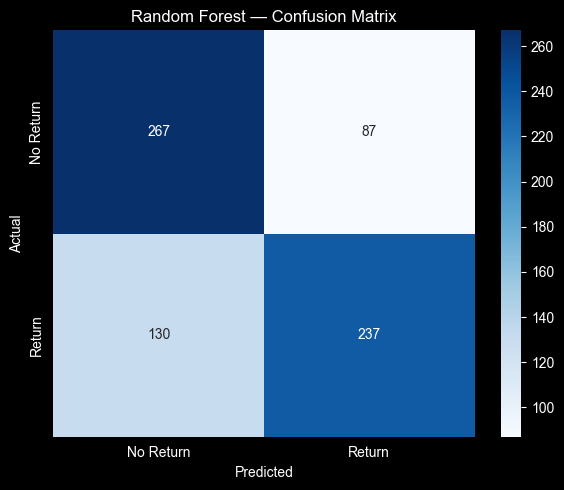

In [7]:
FEATURE_COLS = list(X_train.columns)

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Return', 'Return'],
            yticklabels=['No Return', 'Return'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual');
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/rf_confusion_matrix.png', dpi=150)
plt.show()

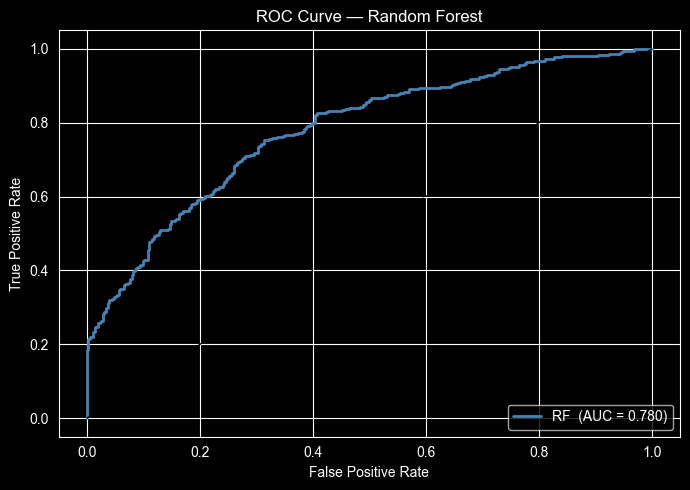

In [8]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'RF  (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/rf_roc_curve.png', dpi=150)
plt.show()

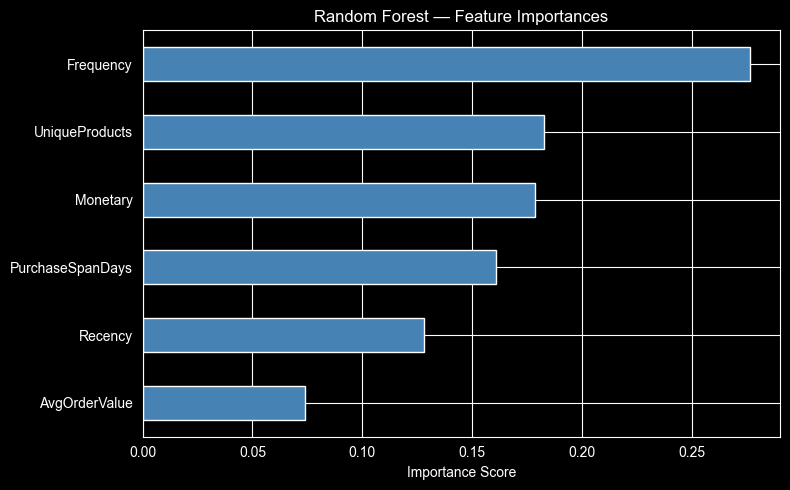

In [9]:
# Feature Importance
importances = pd.Series(best_rf.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind='barh', color='steelblue', figsize=(8, 5))
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/rf_feature_importance.png', dpi=150)
plt.show()

**------------------ 6. SAVE MODEL & RESULTS ---------------------**

In [10]:
with open('../outputs/models/rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)
print("Saved: rf_model.pkl")

Saved: rf_model.pkl


In [11]:
roc_data = pd.DataFrame({'fpr': fpr, 'tpr': tpr})
roc_data.to_csv('../outputs/csv/rf_roc_data.csv', index=False)

In [12]:
# Save metrics summary
pd.DataFrame([{
    'Algorithm': 'Random Forest',
    'Accuracy': round(acc, 4),
    'Precision': round(prec, 4),
    'Recall': round(rec, 4),
    'F1': round(f1, 4),
    'ROC_AUC': round(auc, 4),
    'Best_Params': str(grid_search.best_params_)
}]).to_csv('../outputs/csv/rf_results.csv', index=False)
print("Saved: rf_results.csv, rf_roc_data.csv")

Saved: rf_results.csv, rf_roc_data.csv


* Accuracy : How often correct overall? --> 70%
* Precision : When it says Return, is it right? --> 73%
* Recall : Did it find all real returners? --> 65%
* F1 Score : Balanced precision + recall? --> 0.69
* ROC-AUC : Does it rank customers correctly? --> 78%